In [16]:
import pandas as pd

df = pd.read_csv('../polygraphpy/data/polarizability_data.csv')
df_original = df_original = pd.read_csv('../polygraphpy/data/original_dataset.csv')
df_original = df_original[['smiles', 'mw', 'xlogp', 'polararea', 'complexity', 'rotbonds', 'heavycnt']]
df_original = df_original.rename(columns={'smiles': 'smiles_A'})

In [208]:
from rdkit import Chem

atoms_number = []
for i in df['smiles_A'].values:
    mol = Chem.MolFromSmiles(i)
    mol_with_hs = Chem.AddHs(mol)
    num_all_atoms = mol_with_hs.GetNumAtoms()

    atoms_number.append(num_all_atoms)

df['number_of_atoms'] = atoms_number

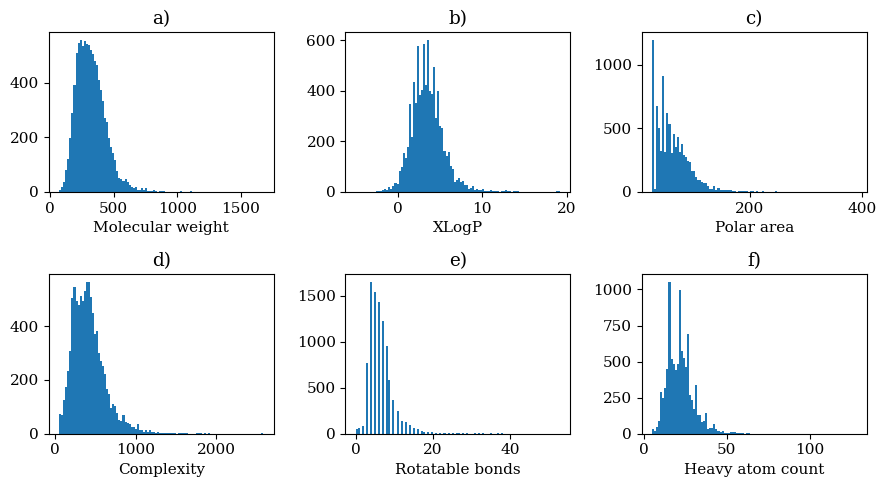

In [37]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,            # Don't require LaTeX
    "mathtext.fontset": "cm",        # Computer Modern math
    "font.family": "serif",          # Generic serif fallback
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

fig = plt.figure(figsize=(9,5))

plt.subplot(2,3,1)
plt.hist(df_original['mw'], bins=100)
plt.xlabel('Molecular weight')
plt.title('a)')

plt.subplot(2,3,2)
plt.hist(df_original['xlogp'], bins=100)
plt.xlabel('XLogP')
plt.title('b)')

plt.subplot(2,3,3)
plt.hist(df_original['polararea'], bins=100)
plt.xlabel('Polar area')
plt.title('c)')

plt.subplot(2,3,4)
plt.hist(df_original['complexity'], bins=100)
plt.xlabel('Complexity')
plt.title('d)')

plt.subplot(2,3,5)
plt.hist(df_original['rotbonds'], bins=100)
plt.xlabel('Rotatable bonds')
plt.title('e)')

plt.subplot(2,3,6)
plt.hist(df_original['heavycnt'], bins=100)
plt.xlabel('Heavy atom count')
plt.title('f)')

plt.tight_layout()
plt.show()
fig.savefig('../figures/Figure_12.pdf')

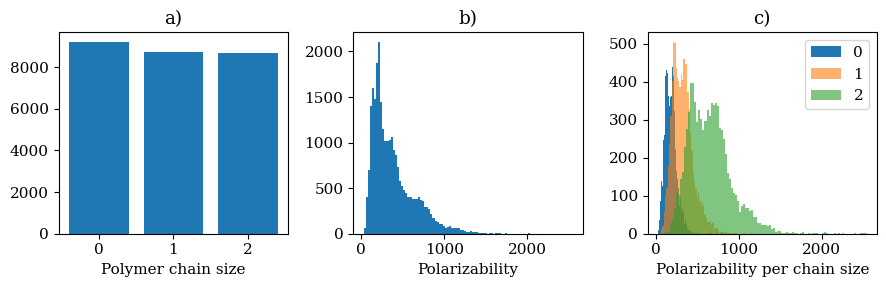

In [60]:
df_homopolymer = pd.read_csv('../polygraphpy/data/polarizability_data.csv')

df_chain_size = df_homopolymer.groupby('chain_size').count().reset_index()

fig = plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.bar(df_chain_size['chain_size'], df_chain_size['id_A'])
plt.xlabel('Polymer chain size')
plt.title('a)')

plt.subplot(1,3,2)
plt.hist(df_homopolymer['static_polarizability'], bins=100)
plt.xlabel('Polarizability')
plt.title('b)')

plt.subplot(1,3,3)
plt.hist(df_homopolymer[df_homopolymer['chain_size'] == 0]['static_polarizability'], bins=100, alpha=1)
plt.hist(df_homopolymer[df_homopolymer['chain_size'] == 1]['static_polarizability'], bins=100, alpha=0.6)
plt.hist(df_homopolymer[df_homopolymer['chain_size'] == 2]['static_polarizability'], bins=100, alpha=0.6)
plt.xlabel('Polarizability per chain size')
plt.legend(['0', '1', '2'])
plt.title('c)')

plt.tight_layout()
plt.show()
fig.savefig('../figures/Figure_13.pdf')

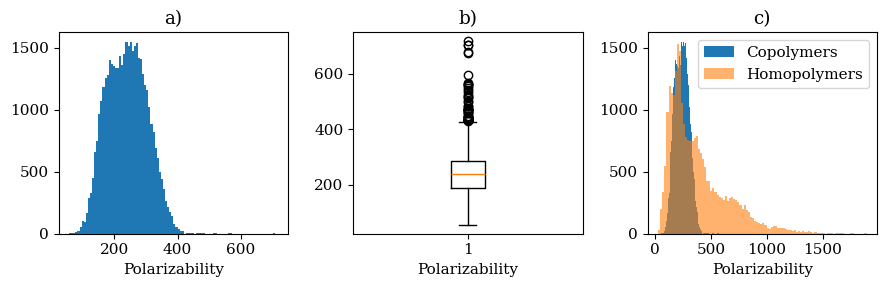

In [203]:
df_copolymer = pd.read_csv('../polygraphpy/data/polarizability_data_copoly.csv')

plt.rcParams.update({
    "text.usetex": False,            # Don't require LaTeX
    "mathtext.fontset": "cm",        # Computer Modern math
    "font.family": "serif",          # Generic serif fallback
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

fig = plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.hist(df_copolymer['static_polarizability'].sort_values()[:-15], bins=100)
plt.xlabel('Polarizability')
plt.title('a)')

plt.subplot(1,3,2)
plt.boxplot(df_copolymer['static_polarizability'].sort_values()[:-15])
plt.xlabel('Polarizability')
plt.title('b)')

plt.subplot(1,3,3)
plt.hist(df_copolymer['static_polarizability'].sort_values()[:-15], bins=100)
plt.hist(df_homopolymer['static_polarizability'].sort_values()[:-15], bins=100, alpha=0.6)
plt.legend(['Copolymers', 'Homopolymers'])
plt.xlabel('Polarizability')
plt.title('c)')

plt.tight_layout()
plt.show()
fig.savefig('../figures/Figure_14.pdf')

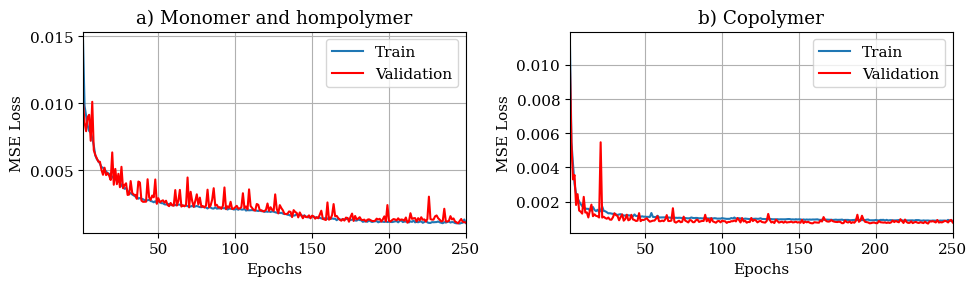

In [222]:
df_training_homopolymer = pd.read_csv('../polygraphpy/data/gnn_output/training_statistics.csv')
df_training_copolymer = pd.read_csv('../polygraphpy/data/gnn_output_copoly/training_statistics_copoly.csv')

fig = plt.figure(figsize=(10,3))

plt.subplot(1,2,1)
plt.plot(df_training_homopolymer['epoch']+1, df_training_homopolymer['train_loss'])
plt.plot(df_training_homopolymer['epoch']+1, df_training_homopolymer['val_loss'], 'r')
plt.grid(1)
plt.xlabel("Epochs")
plt.xlim([1, df_training_homopolymer['epoch'].max() + 1])
plt.title('a) Monomer and hompolymer')
plt.ylabel("MSE Loss")
plt.legend(['Train', 'Validation'])

plt.subplot(1,2,2)
plt.plot(df_training_copolymer['epoch']+1, df_training_copolymer['train_loss'])
plt.plot(df_training_copolymer['epoch']+1, df_training_copolymer['val_loss'], 'r')
plt.grid(1)
plt.xlabel("Epochs")
plt.xlim([1, df_training_copolymer['epoch'].max() + 1])
plt.ylabel("MSE Loss")
plt.title('b) Copolymer')
plt.legend(['Train', 'Validation'])

plt.tight_layout()
plt.show()
fig.savefig(f"../figures/Figure_15.pdf")

In [229]:
df_pred_homopoly = pd.read_csv(f'../polygraphpy/data/gnn_output/df_results.csv')
df_original_homopoly = pd.read_csv(f'../polygraphpy/data/gnn_output/scaled_output.csv')
df_pred_copoly = pd.read_csv(f'../polygraphpy/data/gnn_output_copoly/df_results.csv')
df_original_copoly = pd.read_csv(f'../polygraphpy/data/gnn_output_copoly/scaled_output_copoly.csv')

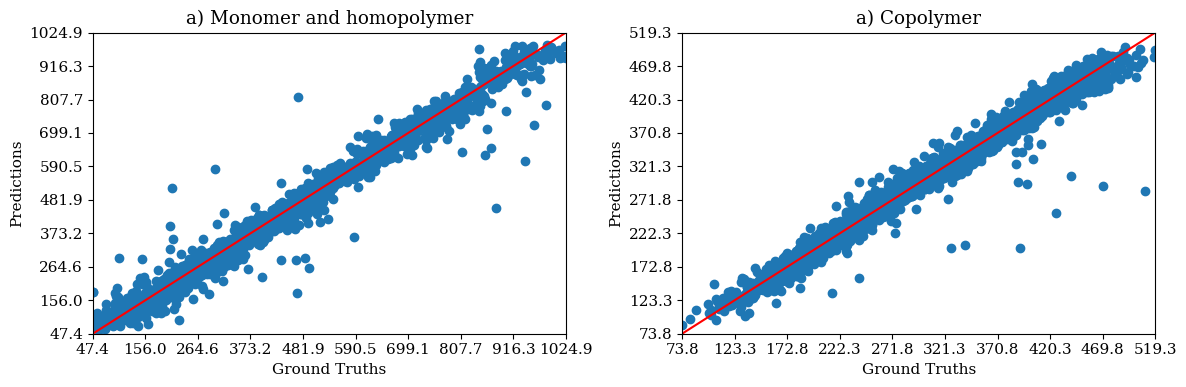

In [243]:
import numpy as np

original_min_homopoly = df_original_homopoly['static_polarizability_original'].min()
original_max_homopoly = df_original_homopoly['static_polarizability_original'].max()
original_min_copoly = df_original_copoly['static_polarizability_original'].min()
original_max_copoly = df_original_copoly['static_polarizability_original'].max()

df_pred_homopoly['y_original'] = df_pred_homopoly['y']*(original_max_homopoly + original_min_homopoly) + original_min_homopoly
df_pred_homopoly['pred_original'] = df_pred_homopoly['pred']*(original_max_homopoly + original_min_homopoly) + original_min_homopoly
df_pred_copoly['y_original'] = df_pred_copoly['y']*(original_max_copoly + original_min_copoly) + original_min_copoly
df_pred_copoly['pred_original'] = df_pred_copoly['pred']*(original_max_copoly + original_min_copoly) + original_min_copoly

fig = plt.figure(figsize=(12,4))

p1 = [df_pred_homopoly['y_original'].min(), df_pred_homopoly['y_original'].max()]
p2 = [df_pred_homopoly['y_original'].min(), df_pred_homopoly['y_original'].max()]
coefficients = np.polyfit(p1, p2, 1)
polynomial = np.poly1d(coefficients)
x_axis = np.linspace(df_pred_homopoly['y_original'].min(), df_pred_homopoly['y_original'].max(), 500)
y_axis = polynomial(x_axis)

plt.subplot(1,2,1)
plt.scatter(df_pred_homopoly['y_original'].values, df_pred_homopoly['pred_original'].values)
plt.plot(x_axis, y_axis, 'r')
plt.xlim(df_pred_homopoly['y_original'].min(), df_pred_homopoly['y_original'].max())
plt.ylim(df_pred_homopoly['y_original'].min(), df_pred_homopoly['y_original'].max())
plt.xticks( np.linspace(df_pred_homopoly['y_original'].min(), df_pred_homopoly['y_original'].max(), 10))
plt.yticks( np.linspace(df_pred_homopoly['y_original'].min(), df_pred_homopoly['y_original'].max(), 10))
plt.title('a) Monomer and homopolymer')
plt.xlabel("Ground Truths")
plt.ylabel("Predictions")

p1 = [df_pred_copoly['y_original'].min(), df_pred_copoly['y_original'].max()]
p2 = [df_pred_copoly['y_original'].min(), df_pred_copoly['y_original'].max()]
coefficients = np.polyfit(p1, p2, 1)
polynomial = np.poly1d(coefficients)
x_axis = np.linspace(df_pred_copoly['y_original'].min(), df_pred_copoly['y_original'].max(), 500)
y_axis = polynomial(x_axis)

plt.subplot(1,2,2)
plt.scatter(df_pred_copoly['y_original'].values, df_pred_copoly['pred_original'].values)
plt.plot(x_axis, y_axis, 'r')
plt.xlim(df_pred_copoly['y_original'].min(), df_pred_copoly['y_original'].max())
plt.ylim(df_pred_copoly['y_original'].min(), df_pred_copoly['y_original'].max())
plt.xticks( np.linspace(df_pred_copoly['y_original'].min(), df_pred_copoly['y_original'].max(), 10))
plt.yticks( np.linspace(df_pred_copoly['y_original'].min(), df_pred_copoly['y_original'].max(), 10))
plt.title('a) Copolymer')
plt.xlabel("Ground Truths")
plt.ylabel("Predictions")

plt.tight_layout()
plt.show()
fig.savefig(f"../figures/Figure_16.pdf")